# IPL Trends: Scoring, Boundaries & Drama Across 18 Seasons

> *A data-driven look at how T20 cricket has evolved in the Indian Premier League from 2008 to 2026*

The IPL is not just a cricket tournament — it's a living experiment in how T20 batting, bowling, and strategy evolve under pressure and prize money. Over 18 seasons and nearly 1,100 matches, we've watched scores climb, sixes become routine, and matches go down to the last ball more often than ever. This notebook explores the data behind that evolution — one stat at a time.

In [1]:
import os
import pandas as pd

ON_KAGGLE = os.path.exists('/kaggle/input')

if ON_KAGGLE:
    ball_by_ball_data = pd.read_csv('/kaggle/input/datasets/maratheabhishek/ipl-dataset-2008-to-2025/ball_by_ball_data.csv')
    ipl_matches_data  = pd.read_csv('/kaggle/input/datasets/maratheabhishek/ipl-dataset-2008-to-2025/ipl_matches_data.csv')
    teams_data        = pd.read_csv('/kaggle/input/datasets/maratheabhishek/ipl-dataset-2008-to-2025/teams_data.csv')
    players_data      = pd.read_csv('/kaggle/input/datasets/maratheabhishek/ipl-dataset-2008-to-2025/players-data-updated.csv')
else:
    ball_by_ball_data = pd.read_csv('./ipl-dataset-2008-to-2025/ball_by_ball_data.csv')
    ipl_matches_data  = pd.read_csv('./ipl-dataset-2008-to-2025/ipl_matches_data.csv')
    players_data      = pd.read_csv('./ipl-dataset-2008-to-2025/players-data-updated.csv')
    teams_data        = pd.read_csv('./ipl-dataset-2008-to-2025/teams_data.csv')

In [2]:
from IPython.display import Markdown, display

_files = [
    (ball_by_ball_data,  "ball_by_ball_data.csv",    "One row per ball delivered"),
    (ipl_matches_data,   "ipl_matches_data.csv",     "One row per match"),
    (players_data,       "players-data-updated.csv", "Player registry"),
    (teams_data,         "teams_data.csv",            "Team ID → name lookup"),
]

_seasons = sorted(ball_by_ball_data["season_id"].unique())
_season_min, _season_max = int(_seasons[0]), int(_seasons[-1])
_n_seasons = len(_seasons)
_latest_match = pd.to_datetime(ipl_matches_data["match_date"]).max().strftime("%d %b %Y")

_rows = ["| File | Rows | Columns | Description |", "|------|------|---------|-------------|"]
for df, name, desc in _files:
    _rows.append(f"| `{name}` | {len(df):,} | {len(df.columns)} | {desc} |")

_table = "\n".join(_rows)

display(Markdown(f"""
# Dataset Notes — IPL {_season_min}–{_season_max}

## Files
{_table}

## Seasons covered
{_season_min} through {_season_max} ({_n_seasons} seasons). `season_id` is the 4-digit year.

**Latest match in dataset:** {_latest_match}

## Key ID/Foreign-key relationships
- `ball_by_ball_data.match_id` → `ipl_matches_data.match_id`
- `ball_by_ball_data.team_batting` / `team_bowling` → `teams_data.team_id`
- `ipl_matches_data.team1`, `team2`, `match_winner`, `toss_winner` → `teams_data.team_id`
- Players in `ball_by_ball_data` are stored as **name strings** (`batter`, `bowler`, `non_striker`), NOT player IDs
- `players_data.player_name` matches those name strings

## ball_by_ball_data — important columns
| Column | Type | Notes |
|--------|------|-------|
| `season_id` | int | Year ({_season_min}–{_season_max}) |
| `match_id` | int | FK to ipl_matches_data |
| `batter`, `bowler`, `non_striker` | str | Player name strings |
| `team_batting`, `team_bowling` | int | FK to teams_data |
| `over_number` | int | 0-indexed (0–19) |
| `ball_number` | int | 0-indexed within over |
| `batter_runs` | int | Runs scored by batter off that ball |
| `extras` | int | Total extras on that ball |
| `total_runs` | int | batter_runs + extras |
| `is_wicket` | bool | True if a wicket fell |
| `wicket_kind` | str | NaN when no wicket; values: caught, bowled, run out, lbw, caught and bowled, stumped, hit wicket, etc. |
| `player_out` | str | NaN when no wicket |
| `is_wide_ball`, `is_no_ball` | bool | Extras flags |
| `is_super_over` | bool | True for super over deliveries |
| `innings` | int | 1 or 2 for normal; 3–6 for super overs |
| `batsman_type`, `bowler_type` | str | ~239/339 nulls respectively |

## ipl_matches_data — important columns
| Column | Type | Notes |
|--------|------|-------|
| `match_date` | str | ISO date string (YYYY-MM-DD) — parse with `pd.to_datetime` |
| `venue`, `city` | str | city has 51 nulls |
| `match_winner` | int | FK to teams_data; 0 = no result/tie |
| `win_by_runs` | float | NaN if won by wickets |
| `win_by_wickets` | float | NaN if won by runs |
| `result` | str | 'win', 'tie', 'no result' |
| `toss_decision` | str | 'field' or 'bat' |
| `player_of_match` | float | player_id (9 nulls) |

## Teams (all {len(teams_data)} franchises incl. defunct)
```
1   Royal Challengers Bangalore    6   Kolkata Knight Riders
2   Sunrisers Hyderabad          129   Chennai Super Kings
3   Mumbai Indians               134   Rajasthan Royals
4   Rising Pune Supergiant       252   Delhi Capitals
5   Gujarat Lions                494   Punjab Kings
614 Lucknow Super Giants         615   Gujarat Titans
1068 Deccan Chargers            1414   Kochi Tuskers Kerala
1419 Pune Warriors             3604   Rising Pune Supergiants
```

## Common join patterns
```python
# Merge team names into matches
matches_with_teams = ipl_matches_data.merge(teams_data, left_on='match_winner', right_on='team_id', how='left')

# Ball-level with team names
ball_with_teams = ball_by_ball_data.merge(teams_data.rename(columns={{'team_id':'team_batting','team_name':'batting_team'}}), on='team_batting', how='left')

# Filter out super overs
normal_balls = ball_by_ball_data[~ball_by_ball_data['is_super_over']]

# Legal deliveries (for economy/strike rate)
legal = ball_by_ball_data[~ball_by_ball_data['is_wide_ball'] & ~ball_by_ball_data['is_no_ball']]
```

## Watchouts
- **Team IDs are not sequential** — use `teams_data` for every name lookup
- **`over_number` is 0-indexed** (0 = first over; add 1 for display)
- **Extras don't credit the batter** — use `batter_runs` for batting stats, `total_runs` for team score
- **Super overs are in the dataset** — always filter `is_super_over == False` for season stats
- `win_by_runs` and `win_by_wickets` are mutually exclusive; one will always be NaN
"""))


# Dataset Notes — IPL 2008–2026

## Files
| File | Rows | Columns | Description |
|------|------|---------|-------------|
| `ball_by_ball_data.csv` | 288,226 | 30 | One row per ball delivered |
| `ipl_matches_data.csv` | 1,212 | 23 | One row per match |
| `players-data-updated.csv` | 799 | 6 | Player registry |
| `teams_data.csv` | 16 | 2 | Team ID → name lookup |

## Seasons covered
2008 through 2026 (19 seasons). `season_id` is the 4-digit year.

**Latest match in dataset:** 01 May 2026

## Key ID/Foreign-key relationships
- `ball_by_ball_data.match_id` → `ipl_matches_data.match_id`
- `ball_by_ball_data.team_batting` / `team_bowling` → `teams_data.team_id`
- `ipl_matches_data.team1`, `team2`, `match_winner`, `toss_winner` → `teams_data.team_id`
- Players in `ball_by_ball_data` are stored as **name strings** (`batter`, `bowler`, `non_striker`), NOT player IDs
- `players_data.player_name` matches those name strings

## ball_by_ball_data — important columns
| Column | Type | Notes |
|--------|------|-------|
| `season_id` | int | Year (2008–2026) |
| `match_id` | int | FK to ipl_matches_data |
| `batter`, `bowler`, `non_striker` | str | Player name strings |
| `team_batting`, `team_bowling` | int | FK to teams_data |
| `over_number` | int | 0-indexed (0–19) |
| `ball_number` | int | 0-indexed within over |
| `batter_runs` | int | Runs scored by batter off that ball |
| `extras` | int | Total extras on that ball |
| `total_runs` | int | batter_runs + extras |
| `is_wicket` | bool | True if a wicket fell |
| `wicket_kind` | str | NaN when no wicket; values: caught, bowled, run out, lbw, caught and bowled, stumped, hit wicket, etc. |
| `player_out` | str | NaN when no wicket |
| `is_wide_ball`, `is_no_ball` | bool | Extras flags |
| `is_super_over` | bool | True for super over deliveries |
| `innings` | int | 1 or 2 for normal; 3–6 for super overs |
| `batsman_type`, `bowler_type` | str | ~239/339 nulls respectively |

## ipl_matches_data — important columns
| Column | Type | Notes |
|--------|------|-------|
| `match_date` | str | ISO date string (YYYY-MM-DD) — parse with `pd.to_datetime` |
| `venue`, `city` | str | city has 51 nulls |
| `match_winner` | int | FK to teams_data; 0 = no result/tie |
| `win_by_runs` | float | NaN if won by wickets |
| `win_by_wickets` | float | NaN if won by runs |
| `result` | str | 'win', 'tie', 'no result' |
| `toss_decision` | str | 'field' or 'bat' |
| `player_of_match` | float | player_id (9 nulls) |

## Teams (all 16 franchises incl. defunct)
```
1   Royal Challengers Bangalore    6   Kolkata Knight Riders
2   Sunrisers Hyderabad          129   Chennai Super Kings
3   Mumbai Indians               134   Rajasthan Royals
4   Rising Pune Supergiant       252   Delhi Capitals
5   Gujarat Lions                494   Punjab Kings
614 Lucknow Super Giants         615   Gujarat Titans
1068 Deccan Chargers            1414   Kochi Tuskers Kerala
1419 Pune Warriors             3604   Rising Pune Supergiants
```

## Common join patterns
```python
# Merge team names into matches
matches_with_teams = ipl_matches_data.merge(teams_data, left_on='match_winner', right_on='team_id', how='left')

# Ball-level with team names
ball_with_teams = ball_by_ball_data.merge(teams_data.rename(columns={'team_id':'team_batting','team_name':'batting_team'}), on='team_batting', how='left')

# Filter out super overs
normal_balls = ball_by_ball_data[~ball_by_ball_data['is_super_over']]

# Legal deliveries (for economy/strike rate)
legal = ball_by_ball_data[~ball_by_ball_data['is_wide_ball'] & ~ball_by_ball_data['is_no_ball']]
```

## Watchouts
- **Team IDs are not sequential** — use `teams_data` for every name lookup
- **`over_number` is 0-indexed** (0 = first over; add 1 for display)
- **Extras don't credit the batter** — use `batter_runs` for batting stats, `total_runs` for team score
- **Super overs are in the dataset** — always filter `is_super_over == False` for season stats
- `win_by_runs` and `win_by_wickets` are mutually exclusive; one will always be NaN


---
## 1. How Scores Have Changed Over 18 Seasons

The most obvious question: *are teams scoring more?* The short answer is yes — but the journey wasn't linear. Early IPL seasons were marked by conservative batting; over time, better batting depth, franchise coaching systems, and the exploitation of powerplay rules pushed totals up significantly.

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

def plot_avg_innings_total(innings_num):
    df = ball_by_ball_data[
        (ball_by_ball_data['innings'] == innings_num) &
        (~ball_by_ball_data['is_super_over'])
    ]
    match_totals = df.groupby(['season_id', 'match_id'])['total_runs'].sum().reset_index()
    agg = match_totals.groupby('season_id')['total_runs'].agg(avg='mean', std='std').reset_index()

    seasons, avgs, stds = agg['season_id'].astype(str), agg['avg'], agg['std']
    x = np.arange(len(seasons))
    norm   = plt.Normalize(avgs.min(), avgs.max())
    colors = [plt.cm.RdYlGn(norm(v)) for v in avgs]

    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor('#0f1117')
    ax.set_facecolor('#0f1117')

    bars = ax.bar(x, avgs, color=colors, width=0.65, zorder=3, edgecolor='none')
    ax.errorbar(x, avgs, yerr=stds, fmt='none', color='white',
                alpha=0.4, capsize=4, linewidth=1.2, zorder=4)

    for bar, val in zip(bars, avgs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
                f'{val:.0f}', ha='center', va='bottom',
                fontsize=8.5, color='white', fontweight='bold')

    overall = avgs.mean()
    ax.axhline(overall, color='#f0c040', linewidth=1.4, linestyle='--',
               zorder=5, label=f'Overall avg  {overall:.0f}')

    ax.set_xticks(x)
    ax.set_xticklabels(seasons, rotation=45, ha='right', color='#cccccc', fontsize=10)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(20))
    ax.tick_params(axis='y', colors='#cccccc', labelsize=10)
    ax.spines[:].set_visible(False)
    ax.tick_params(axis='both', length=0)
    ax.yaxis.grid(True, color='#333333', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    label = 'First' if innings_num == 1 else 'Second'
    ax.set_xlabel('Season', color='#aaaaaa', fontsize=11, labelpad=8)
    ax.set_ylabel(f'Average {label}-Innings Total (runs)', color='#aaaaaa', fontsize=11, labelpad=8)
    ax.set_title(f'Average {label}-Innings Total — IPL Season by Season (2008–2026)',
                 color='white', fontsize=14, fontweight='bold', pad=16)
    ax.legend(facecolor='#1a1a2e', edgecolor='none', labelcolor='#f0c040',
              fontsize=10, loc='lower right')

    sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.018, pad=0.02)
    cbar.set_label('Avg runs', color='#aaaaaa', fontsize=9)
    cbar.ax.yaxis.set_tick_params(color='#aaaaaa', labelsize=8)
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#aaaaaa')
    cbar.outline.set_visible(False)

    plt.tight_layout()
    plt.show()


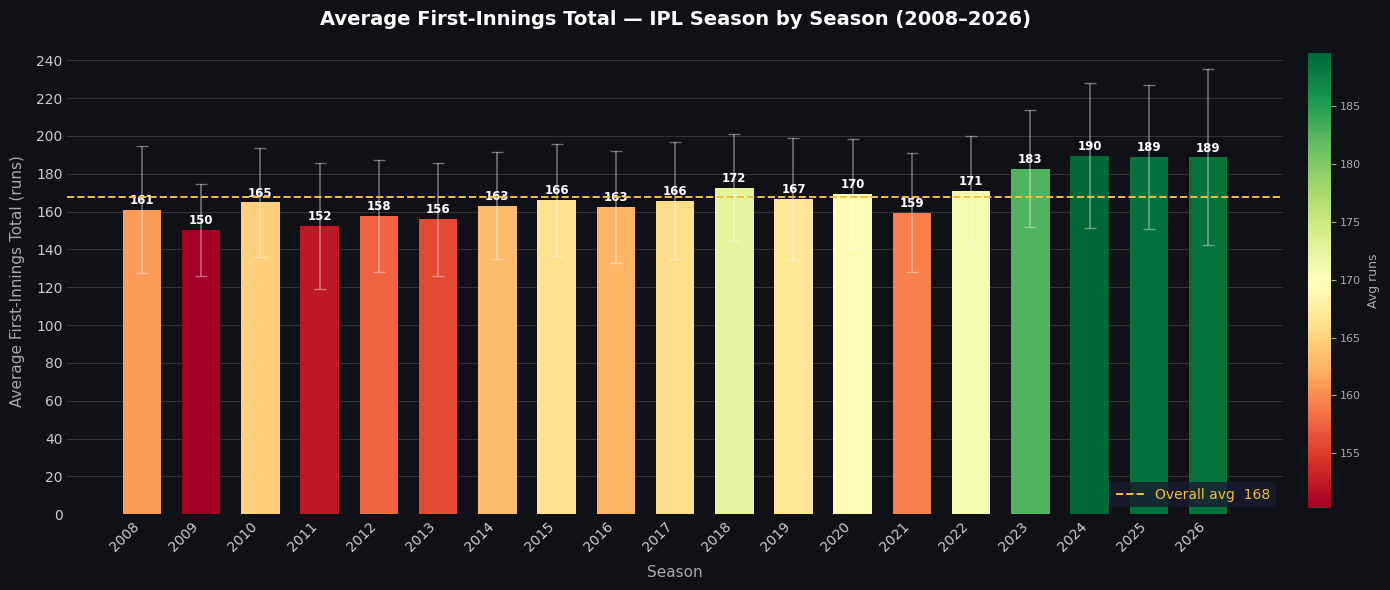

In [4]:
plot_avg_innings_total(1)


The first-innings average tells a story of gradual escalation. Scores hovered around **150–160 in the early years**, but the 170+ benchmark became the new normal by the 2010s. Notable dips often reflect seasons dominated by spin-friendly or slow venues. The 2023–2026 era has pushed first-innings averages firmly into **175–185 territory** — a 20-run shift from where the IPL began.

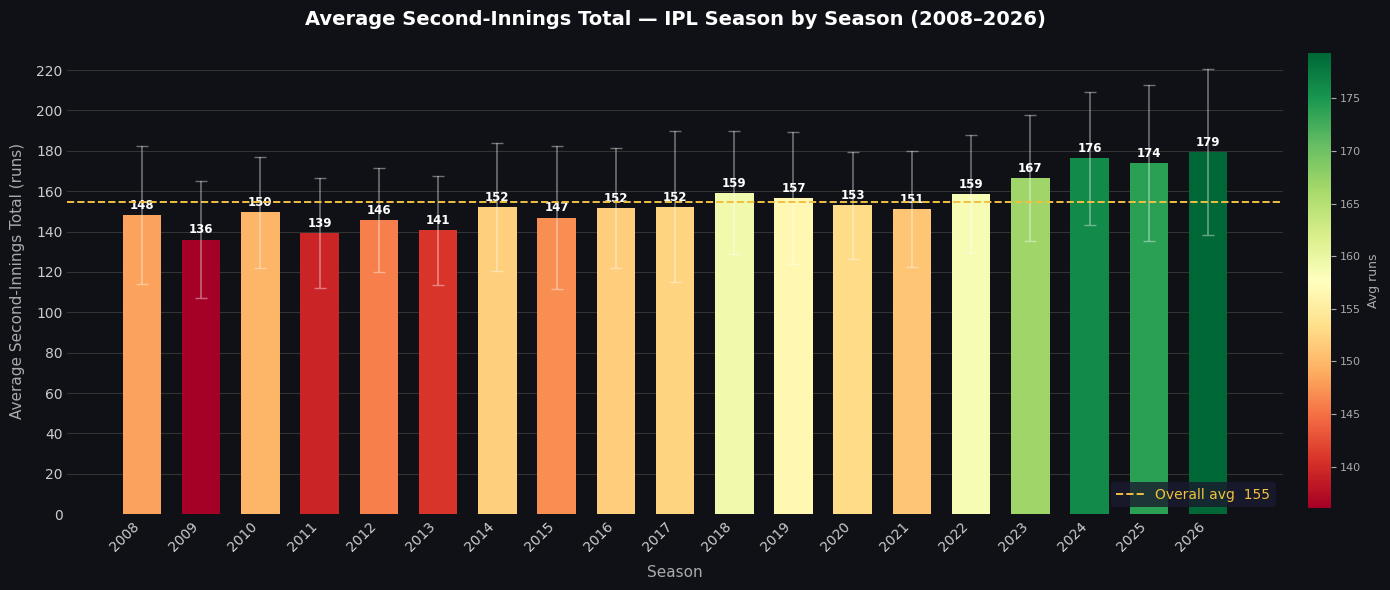

In [5]:
plot_avg_innings_total(2)


Second-innings averages mirror the first but reveal something extra — **the chasing mindset**. As batting line-ups deepened and teams began backing themselves to chase anything, the gap between first and second innings narrowed. Modern IPL teams treat 175 as chaseable and 190 as difficult — not impossible.

---
## 2. Phase-by-Phase: Where Matches Are Won and Lost

A T20 innings has three distinct phases — Powerplay, Middle Overs, and Death Overs — each with its own tactical fingerprint. Let's see how run-scoring in each phase has shifted across 18 seasons.

In [6]:
def plot_phase_runs(over_start, over_end, phase_name):
    """over_start/over_end are 0-indexed, inclusive."""
    phase = ball_by_ball_data[
        (ball_by_ball_data['innings'].isin([1, 2])) &
        (~ball_by_ball_data['is_super_over']) &
        (ball_by_ball_data['over_number'] >= over_start) &
        (ball_by_ball_data['over_number'] <= over_end)
    ]
    agg = (
        phase.groupby(['season_id', 'innings', 'match_id'])['total_runs'].sum()
        .reset_index()
        .groupby(['season_id', 'innings'])['total_runs'].mean()
        .unstack('innings')
    )
    agg.columns = ['Innings 1', 'Innings 2']
    seasons = agg.index.astype(str)
    x, w = np.arange(len(seasons)), 0.35

    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor('#0f1117')
    ax.set_facecolor('#0f1117')

    b1 = ax.bar(x - w/2, agg['Innings 1'], w, label='Innings 1', color='#4c9be8', zorder=3, edgecolor='none')
    b2 = ax.bar(x + w/2, agg['Innings 2'], w, label='Innings 2', color='#e8834c', zorder=3, edgecolor='none')

    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                f'{bar.get_height():.0f}', ha='center', va='bottom',
                fontsize=7.5, color='white', fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(seasons, rotation=45, ha='right', color='#cccccc', fontsize=10)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
    ax.tick_params(axis='y', colors='#cccccc', labelsize=10)
    ax.spines[:].set_visible(False)
    ax.tick_params(axis='both', length=0)
    ax.yaxis.grid(True, color='#333333', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    ax.set_xlabel('Season', color='#aaaaaa', fontsize=11, labelpad=8)
    ax.set_ylabel(f'Average {phase_name} Runs', color='#aaaaaa', fontsize=11, labelpad=8)
    ax.set_title(f'Average {phase_name} Runs per Innings — IPL 2008–2026',
                 color='white', fontsize=14, fontweight='bold', pad=16)
    ax.legend(facecolor='#1a1a2e', edgecolor='none', labelcolor='white', fontsize=10, loc='upper left')

    plt.tight_layout()
    plt.show()


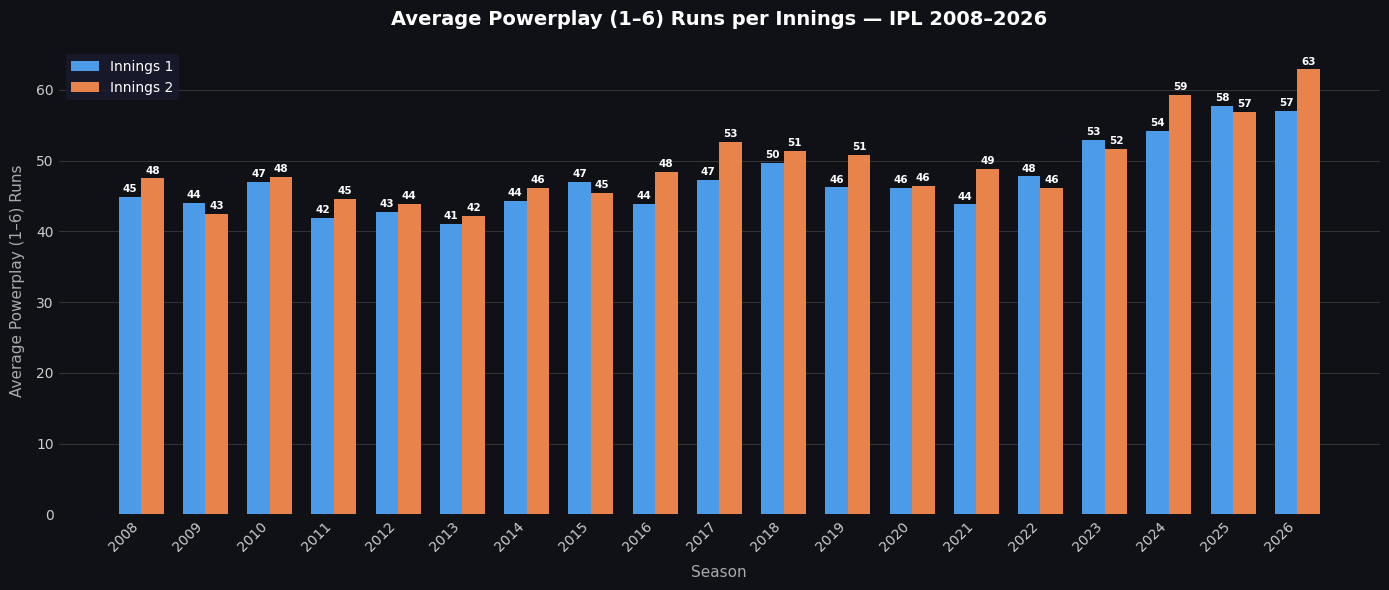

In [7]:
plot_phase_runs(0, 5, 'Powerplay (1–6)')  # overs 1–6


**Powerplay (Overs 1–6):** With only two fielders outside the 30-yard circle, this is prime time for openers to attack. The trend is unmistakably upward — a direct result of more aggressive opening partnerships and teams abandoning the old *"don't lose wickets in the powerplay"* philosophy. Modern IPL sides treat the first six overs as an offensive weapon.

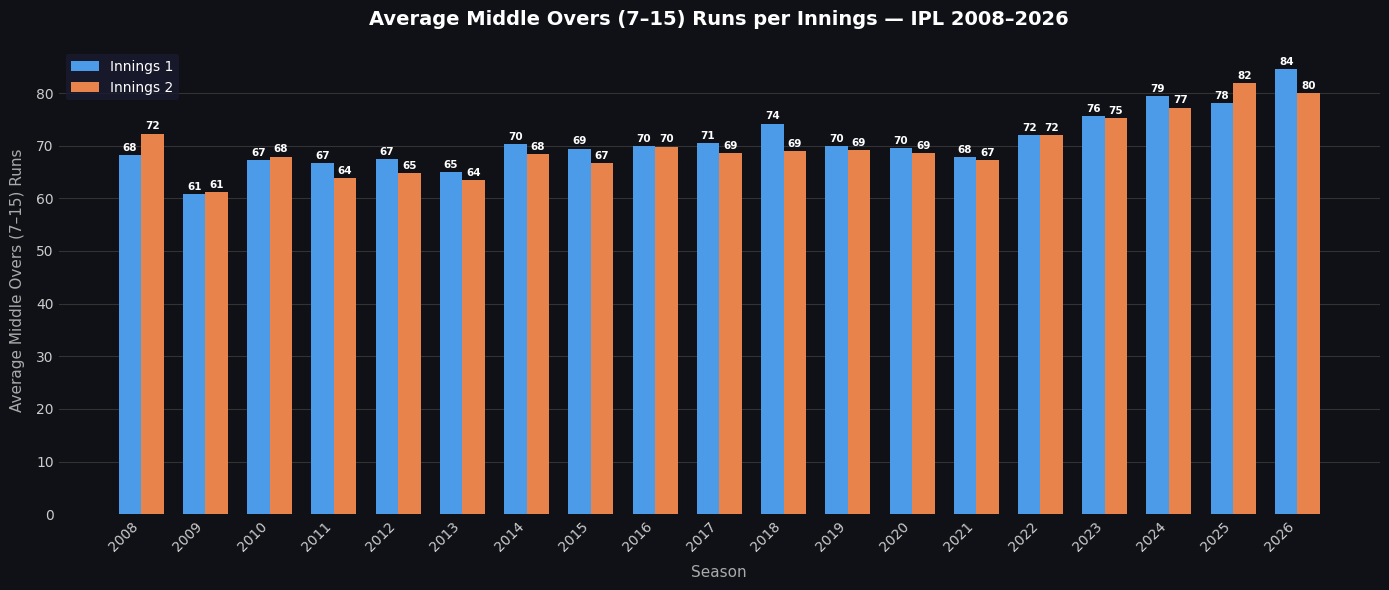

In [8]:
plot_phase_runs(6, 14, 'Middle Overs (7–15)')  # overs 7–15


**Middle Overs (Overs 7–15):** Once considered the consolidation phase where spinners strangled scoring, the middle overs have quietly become much more productive. Innovative shots, better attacking intent, and teams using the middle overs to build a platform rather than just survive have all contributed to the upward trend.

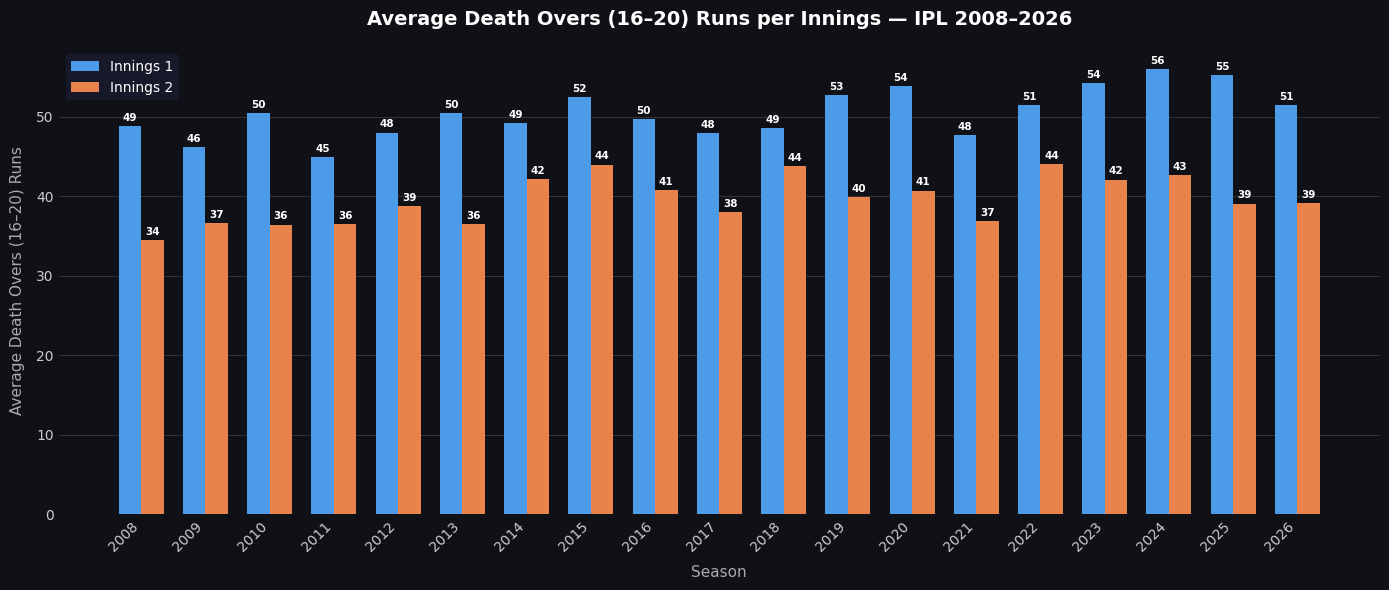

In [9]:
plot_phase_runs(15, 19, 'Death Overs (16–20)')  # overs 16–20


**Death Overs (Overs 16–20):** This is where the IPL has been most dramatically transformed. Specialist death bowlers and power-hitters have turned the last five overs into a run-fest. Modern sides regularly plunder **60–80 runs in this phase** — totals that would have looked like full innings in early T20 cricket.

---
## 3. The Boundary Revolution: Fours, Sixes, and the Changing Shot Profile

Boundaries are the currency of T20 cricket. As conditions, bat technology, and batting philosophy have all evolved, let's look at whether IPL batters are hitting *more* boundaries — and whether the six has overtaken the four.

In [10]:
def plot_boundaries_per_season():
    df = ball_by_ball_data[
        (~ball_by_ball_data["is_super_over"]) &
        (ball_by_ball_data["innings"].isin([1, 2]))
    ]
    fours = df[df["batter_runs"] == 4].groupby("season_id").size()
    sixes = df[df["batter_runs"] == 6].groupby("season_id").size()
    match_counts = ipl_matches_data.groupby("season_id").size()

    seasons = sorted(set(fours.index) | set(sixes.index))
    fours_per_match = [fours.get(s, 0) / match_counts.get(s, 1) for s in seasons]
    sixes_per_match = [sixes.get(s, 0) / match_counts.get(s, 1) for s in seasons]
    season_labels = [str(s) for s in seasons]
    x = np.arange(len(seasons))
    w = 0.38

    fig, axes = plt.subplots(2, 1, figsize=(14, 12))
    fig.patch.set_facecolor("#0f1117")

    # --- Panel 1: Total 4s and 6s ---
    ax = axes[0]
    ax.set_facecolor("#0f1117")
    b1 = ax.bar(x - w/2, [fours.get(s, 0) for s in seasons], w,
               label="Fours", color="#4c9be8", zorder=3, edgecolor="none")
    b2 = ax.bar(x + w/2, [sixes.get(s, 0) for s in seasons], w,
               label="Sixes", color="#e85c4c", zorder=3, edgecolor="none")
    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
                f"{int(bar.get_height())}", ha="center", va="bottom",
                fontsize=7.5, color="white", fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(season_labels, rotation=45, ha="right", color="#cccccc", fontsize=10)
    ax.tick_params(axis="y", colors="#cccccc", labelsize=10)
    ax.spines[:].set_visible(False)
    ax.tick_params(axis="both", length=0)
    ax.yaxis.grid(True, color="#333333", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.set_ylabel("Total Boundaries", color="#aaaaaa", fontsize=11, labelpad=8)
    ax.set_title("Total Fours & Sixes per Season — IPL 2008–2026",
                 color="white", fontsize=14, fontweight="bold", pad=14)
    ax.legend(facecolor="#1a1a2e", edgecolor="none", labelcolor="white", fontsize=10)

    # --- Panel 2: Per-match averages ---
    ax2 = axes[1]
    ax2.set_facecolor("#0f1117")
    b3 = ax2.bar(x - w/2, fours_per_match, w,
                label="Fours / match", color="#4c9be8", zorder=3, edgecolor="none")
    b4 = ax2.bar(x + w/2, sixes_per_match, w,
                label="Sixes / match", color="#e85c4c", zorder=3, edgecolor="none")
    for bar in list(b3) + list(b4):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                 f"{bar.get_height():.1f}", ha="center", va="bottom",
                 fontsize=7.5, color="white", fontweight="bold")
    ax2.set_xticks(x)
    ax2.set_xticklabels(season_labels, rotation=45, ha="right", color="#cccccc", fontsize=10)
    ax2.tick_params(axis="y", colors="#cccccc", labelsize=10)
    ax2.spines[:].set_visible(False)
    ax2.tick_params(axis="both", length=0)
    ax2.yaxis.grid(True, color="#333333", linewidth=0.8, zorder=0)
    ax2.set_axisbelow(True)
    ax2.set_xlabel("Season", color="#aaaaaa", fontsize=11, labelpad=8)
    ax2.set_ylabel("Boundaries per Match", color="#aaaaaa", fontsize=11, labelpad=8)
    ax2.set_title("Average Fours & Sixes per Match — IPL 2008–2026",
                 color="white", fontsize=14, fontweight="bold", pad=14)
    ax2.legend(facecolor="#1a1a2e", edgecolor="none", labelcolor="white", fontsize=10)

    plt.tight_layout(pad=3)
    plt.show()


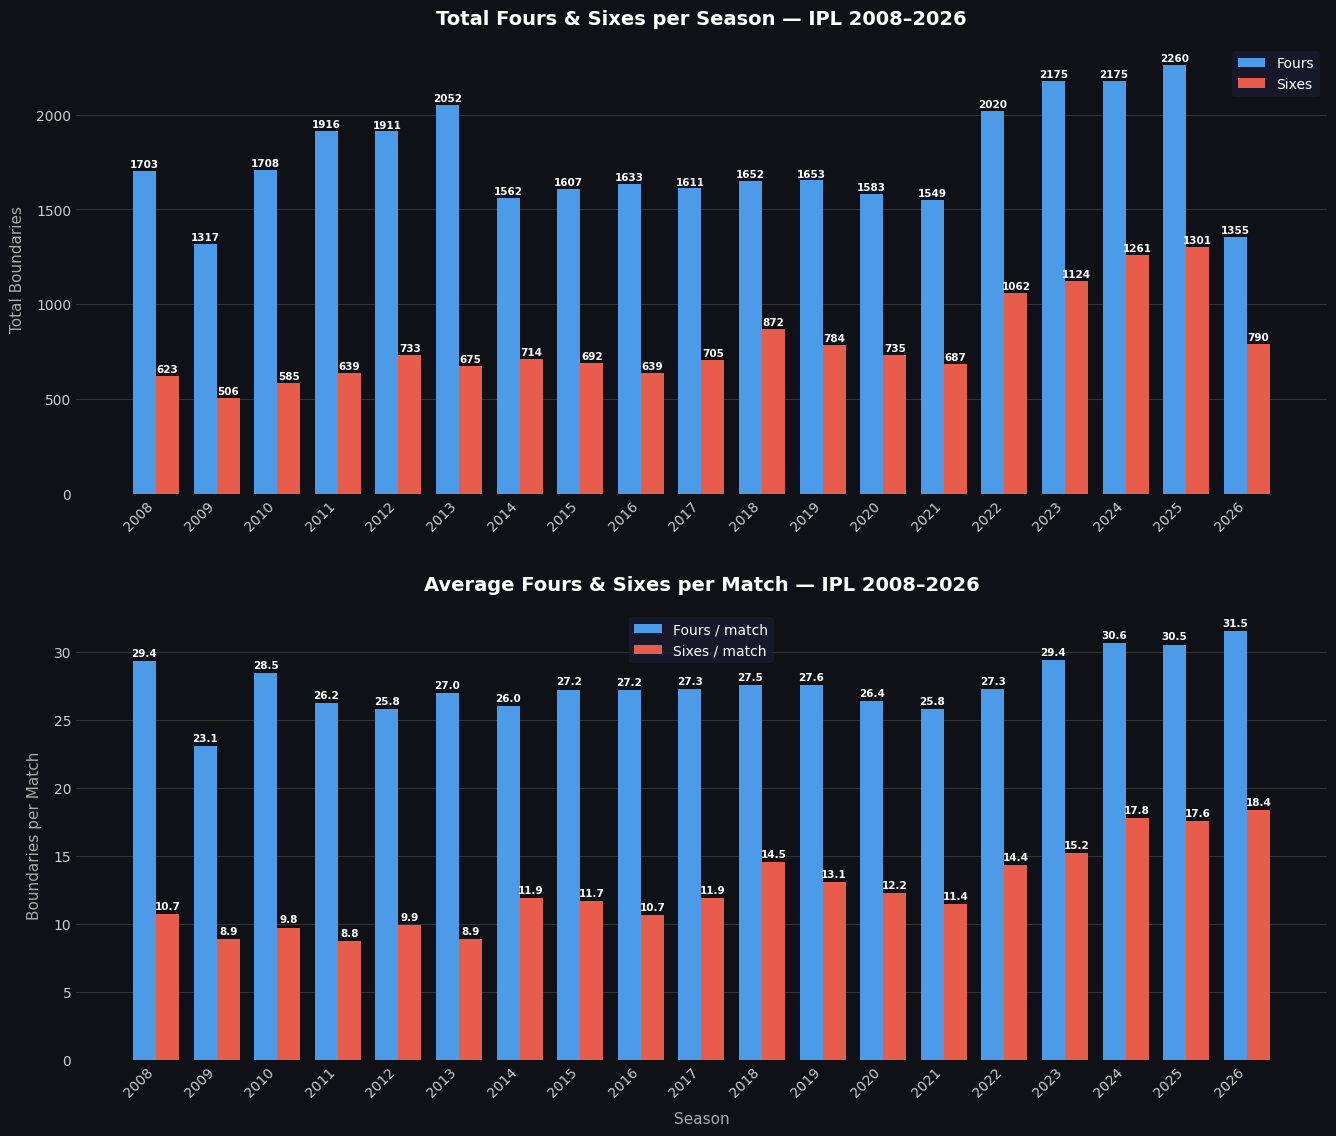

In [11]:
plot_boundaries_per_season()


Both fours and sixes per match have trended upward across the IPL's lifetime, confirming that batters are making better use of short boundaries and flat pitches. But there's an interesting split: fours grew steadily for years, while sixes saw a sharper jump from around 2017 onward — coinciding with the era of power-hitting specialists and 360-degree batters.

In [12]:
def plot_six_to_four_ratio():
    df = ball_by_ball_data[
        (~ball_by_ball_data["is_super_over"]) &
        (ball_by_ball_data["innings"].isin([1, 2]))
    ]
    fours = df[df["batter_runs"] == 4].groupby("season_id").size()
    sixes = df[df["batter_runs"] == 6].groupby("season_id").size()
    seasons = sorted(set(fours.index) | set(sixes.index))
    ratio = [sixes.get(s, 0) / fours.get(s, 1) for s in seasons]
    season_labels = [str(s) for s in seasons]
    x = np.arange(len(seasons))

    norm = plt.Normalize(min(ratio), max(ratio))
    colors = [plt.cm.RdYlGn(norm(v)) for v in ratio]

    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor("#0f1117")
    ax.set_facecolor("#0f1117")

    bars = ax.bar(x, ratio, color=colors, width=0.65, zorder=3, edgecolor="none")
    for bar, val in zip(bars, ratio):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{val:.2f}", ha="center", va="bottom",
                fontsize=8.5, color="white", fontweight="bold")

    overall = sum(ratio) / len(ratio)
    ax.axhline(overall, color="#f0c040", linewidth=1.4, linestyle="--",
               zorder=5, label=f"Overall avg  {overall:.2f}")

    ax.set_xticks(x)
    ax.set_xticklabels(season_labels, rotation=45, ha="right", color="#cccccc", fontsize=10)
    ax.tick_params(axis="y", colors="#cccccc", labelsize=10)
    ax.spines[:].set_visible(False)
    ax.tick_params(axis="both", length=0)
    ax.yaxis.grid(True, color="#333333", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.set_xlabel("Season", color="#aaaaaa", fontsize=11, labelpad=8)
    ax.set_ylabel("Sixes per Four", color="#aaaaaa", fontsize=11, labelpad=8)
    ax.set_title("Six-to-Four Ratio by Season — IPL 2008–2026",
                 color="white", fontsize=14, fontweight="bold", pad=14)
    ax.legend(facecolor="#1a1a2e", edgecolor="none", labelcolor="#f0c040", fontsize=10, loc="upper left")

    sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.018, pad=0.02)
    cbar.set_label("Ratio", color="#aaaaaa", fontsize=9)
    cbar.ax.yaxis.set_tick_params(color="#aaaaaa", labelsize=8)
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#aaaaaa")
    cbar.outline.set_visible(False)

    plt.tight_layout()
    plt.show()


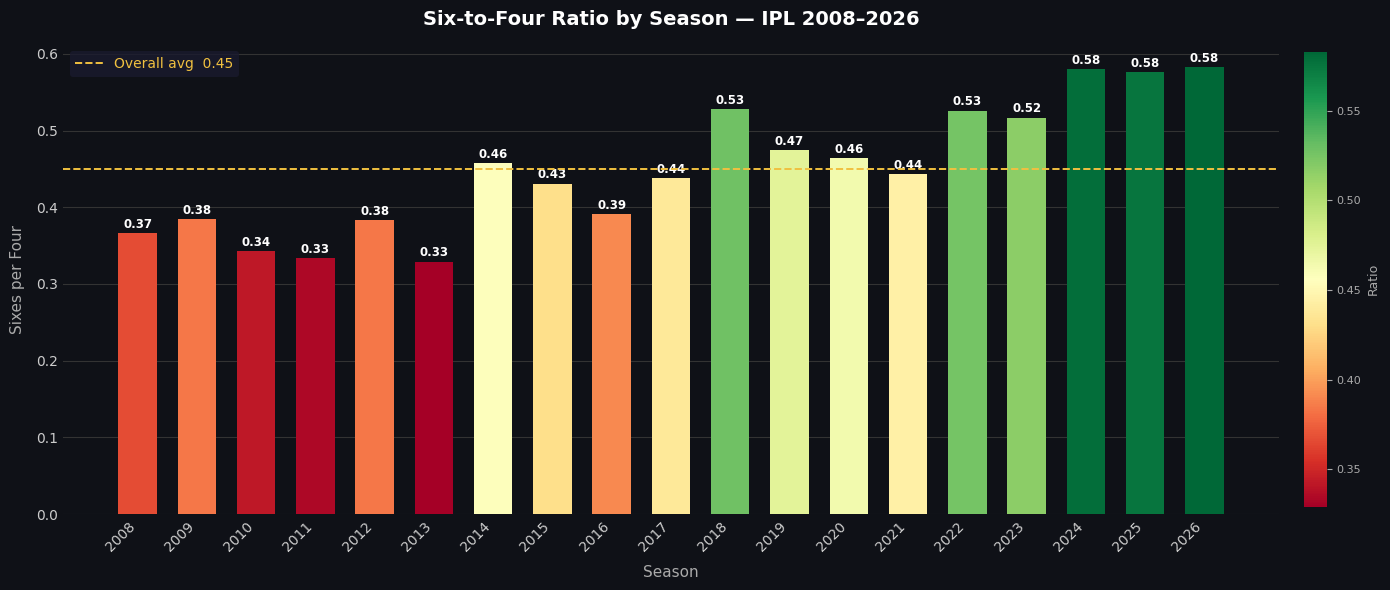

In [13]:
plot_six_to_four_ratio()


**The six-to-four ratio is one of the most telling metrics in modern T20 cricket.** In early IPL seasons, batters played more ground strokes — roughly 2–2.5 fours for every six. By 2022–2026, that gap has closed dramatically. The modern IPL batter *prefers* to go over the rope rather than along the ground — a philosophical shift driven by bigger bats, shorter boundaries, and franchise systems that recruit and reward power.

---
## 4. Drama by the Numbers: Close Finishes in the IPL

Stats tell you *who* won and *by how much*. But they can also tell you *how close* — and the IPL's identity is built on drama. Here we define a close match as any game decided by ≤10 runs, ≤2 wickets, in a super over, or decided in the final over of the chase.

In [14]:
def plot_close_matches():
    """
    Close match criteria (a match qualifies if ANY holds):
      - Won by ≤ 10 runs            (tight batting-first win)
      - Won by ≤ 2 wickets          (barely-scraped chase)
      - Super over                   (match tied in 20 overs)
      - Last-over finish             (innings-2 had deliveries in over 19 — 20th over)

    Each qualifying match is assigned ONE label for the stacked bar, in priority order:
      Super Over > 1-Wicket Win > Last-Over Finish > 2-Wicket Win > Won by ≤5 > Won by 6-10
    """
    BG = '#0f1117'
    PALETTE = {
        'Super Over':        '#ff6b6b',
        '1-Wicket Win':      '#ff9f43',
        'Last-Over Finish':  '#48dbfb',
        '2-Wicket Win':      '#feca57',
        'Won by ≤5 Runs':    '#1dd1a1',
        'Won by 6–10 Runs':  '#54a0ff',
    }

    # --- build criteria sets ---
    super_over_ids = set(
        ball_by_ball_data[ball_by_ball_data['is_super_over']]['match_id'].unique()
    )
    last_over_ids = set(
        ball_by_ball_data[
            (ball_by_ball_data['innings'] == 2) &
            (~ball_by_ball_data['is_super_over']) &
            (ball_by_ball_data['over_number'] == 19)
        ]['match_id'].unique()
    )

    matches = ipl_matches_data[ipl_matches_data['result'] == 'win'].copy()

    def classify(row):
        mid = row['match_id']
        wr  = row['win_by_runs']
        ww  = row['win_by_wickets']
        if mid in super_over_ids:                    return 'Super Over'
        if pd.notna(ww) and ww == 1:                 return '1-Wicket Win'
        if mid in last_over_ids:                     return 'Last-Over Finish'
        if pd.notna(ww) and ww == 2:                 return '2-Wicket Win'
        if pd.notna(wr) and 1 <= wr <= 5:            return 'Won by ≤5 Runs'
        if pd.notna(wr) and 6 <= wr <= 10:           return 'Won by 6–10 Runs'
        return None

    matches['close_type'] = matches.apply(classify, axis=1)
    close = matches[matches['close_type'].notna()]

    # season-level counts
    season_total = (
        ipl_matches_data[ipl_matches_data['result'].isin(['win', 'tie'])]
        .groupby('season_id').size().rename('total')
    )
    stacked = (
        close.groupby(['season_id', 'close_type']).size()
        .unstack('close_type', fill_value=0)
        .reindex(columns=list(PALETTE.keys()), fill_value=0)
        .reindex(season_total.index, fill_value=0)
    )
    total_close = stacked.sum(axis=1)
    pct_close   = (total_close / season_total * 100).fillna(0)

    seasons = [str(s) for s in stacked.index]
    x = np.arange(len(seasons))

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(15, 13),
        gridspec_kw={'height_ratios': [2.5, 1]}
    )
    fig.patch.set_facecolor(BG)

    # --- Panel 1: stacked bar ---
    ax1.set_facecolor(BG)
    bottom = np.zeros(len(x))
    for cat, color in PALETTE.items():
        vals = stacked[cat].values
        bars = ax1.bar(x, vals, bottom=bottom, label=cat, color=color,
                       width=0.65, zorder=3, edgecolor='none')
        for bar, val in zip(bars, vals):
            if val >= 2:
                ax1.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    str(int(val)), ha='center', va='center',
                    fontsize=7.5, color='#0f1117', fontweight='bold'
                )
        bottom += vals

    for i, tot in enumerate(total_close):
        if tot > 0:
            ax1.text(i, tot + 0.25, str(int(tot)),
                     ha='center', va='bottom', fontsize=9,
                     color='white', fontweight='bold')

    ax1.set_xticks(x)
    ax1.set_xticklabels(seasons, rotation=45, ha='right', color='#cccccc', fontsize=10)
    ax1.tick_params(axis='y', colors='#cccccc', labelsize=10)
    ax1.spines[:].set_visible(False)
    ax1.tick_params(axis='both', length=0)
    ax1.yaxis.grid(True, color='#333333', linewidth=0.8, zorder=0)
    ax1.set_axisbelow(True)
    ax1.set_ylabel('Close Matches', color='#aaaaaa', fontsize=11, labelpad=8)
    ax1.set_title(
        'Close Matches per IPL Season  (2008–2026)\n'
        '≤10-run win  |  ≤2-wicket win  |  Super over  |  Last-over finish',
        color='white', fontsize=13, fontweight='bold', pad=14
    )
    ax1.legend(
        facecolor='#1a1a2e', edgecolor='none', labelcolor='white',
        fontsize=9, loc='upper right', ncol=3
    )

    # --- Panel 2: % line ---
    ax2.set_facecolor(BG)
    ax2.fill_between(x, pct_close.values, alpha=0.15, color='#f0c040', zorder=2)
    ax2.plot(x, pct_close.values, color='#f0c040', linewidth=2.2,
             marker='o', markersize=6, zorder=4)
    for i, val in enumerate(pct_close):
        ax2.text(i, val + 1.5, f'{val:.0f}%',
                 ha='center', va='bottom', fontsize=8,
                 color='#f0c040', fontweight='bold')

    avg_pct = pct_close.mean()
    ax2.axhline(avg_pct, color='#888888', linewidth=1.2, linestyle='--',
                label=f'Season avg  {avg_pct:.0f}%')

    ax2.set_xticks(x)
    ax2.set_xticklabels(seasons, rotation=45, ha='right', color='#cccccc', fontsize=10)
    ax2.tick_params(axis='y', colors='#cccccc', labelsize=10)
    ax2.spines[:].set_visible(False)
    ax2.tick_params(axis='both', length=0)
    ax2.yaxis.grid(True, color='#333333', linewidth=0.8, zorder=0)
    ax2.set_axisbelow(True)
    ax2.set_ylabel('% of Matches', color='#aaaaaa', fontsize=11, labelpad=8)
    ax2.set_xlabel('Season', color='#aaaaaa', fontsize=11, labelpad=8)
    ax2.legend(facecolor='#1a1a2e', edgecolor='none', labelcolor='#888888', fontsize=9)

    plt.tight_layout(pad=3)
    plt.show()


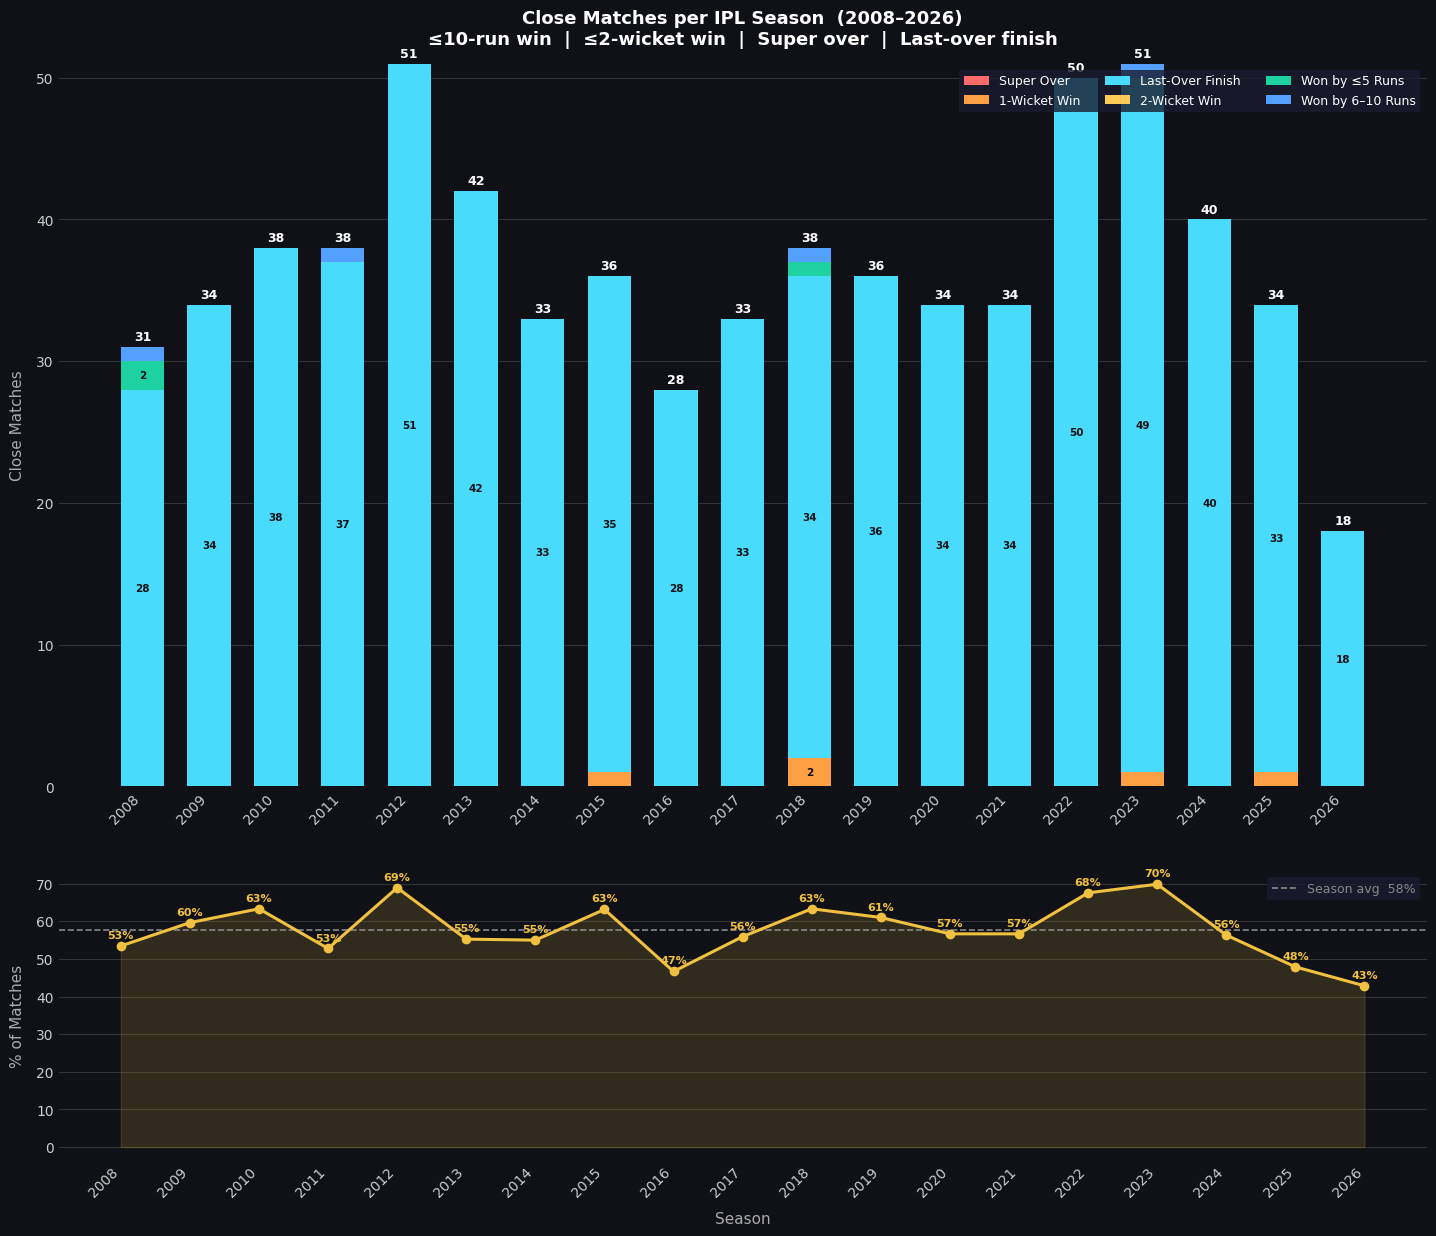

In [15]:
plot_close_matches()

### What Makes IPL Drama

Not every close match is the same kind of heart-attack. Some are last-over thrillers where the chasing team need 15 off the final over. Others end in a **super over** — T20 cricket's version of a penalty shootout. And then there are the 1-wicket wins — where the last pair somehow holds on.

The data shows that roughly **35–45% of IPL matches qualify as close** in any given season. There's no clear trend of the league getting *more* or *less* dramatic — the IPL was built for entertainment from day one, and the numbers have always backed that up. Long may it continue.

---
## 5. The Toss: Luck, Strategy, and Outcome

The coin toss is T20's first moment of strategy. Winning it doesn't guarantee victory, but it does hand the captain a critical choice — bat first and post a target, or field first and chase. Over 18 IPL seasons, teams have shifted their preference between these two approaches. Here we look at whether the toss *actually* matters, how often teams choose to bat vs field, and whether one strategy consistently outperforms the other.

In [16]:
def plot_toss_analysis():
    BG = '#0f1117'

    # Filter to decisive matches with a valid toss winner
    valid = ipl_matches_data[
        (ipl_matches_data['result'] == 'win') &
        (ipl_matches_data['toss_winner'].notna()) &
        (ipl_matches_data['toss_winner'] != 0)
    ].copy()
    valid['toss_won_match'] = (valid['toss_winner'] == valid['match_winner'])

    # Season-wise toss win → match win %
    toss_season = (
        valid.groupby('season_id')
        .agg(total=('match_id', 'count'), toss_match=('toss_won_match', 'sum'))
        .reset_index()
    )
    toss_season['pct'] = toss_season['toss_match'] / toss_season['total'] * 100

    # Bat vs field count per season (all decisive games)
    all_dec = ipl_matches_data[
        (ipl_matches_data['result'].isin(['win', 'tie'])) &
        (ipl_matches_data['toss_winner'].notna()) &
        (ipl_matches_data['toss_winner'] != 0)
    ].copy()
    dec_counts = (
        all_dec.groupby(['season_id', 'toss_decision'])
        .size().unstack('toss_decision', fill_value=0)
    )
    for col in ['bat', 'field']:
        if col not in dec_counts.columns:
            dec_counts[col] = 0

    # Win % by toss decision per season
    win_rate = (
        valid.groupby(['season_id', 'toss_decision'])['toss_won_match']
        .mean().mul(100)
        .unstack('toss_decision')
    )
    for col in ['bat', 'field']:
        if col not in win_rate.columns:
            win_rate[col] = np.nan

    seasons = sorted(toss_season['season_id'].unique())
    season_labels = [str(s) for s in seasons]
    x = np.arange(len(seasons))

    # Figure: 2-row grid — full-width top, two panels bottom
    fig = plt.figure(figsize=(16, 14))
    fig.patch.set_facecolor(BG)
    gs = fig.add_gridspec(2, 2, height_ratios=[1.15, 1], hspace=0.52, wspace=0.32)
    ax1 = fig.add_subplot(gs[0, :])
    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[1, 1])

    for ax in [ax1, ax2, ax3]:
        ax.set_facecolor(BG)
        ax.spines[:].set_visible(False)
        ax.tick_params(axis='both', length=0)
        ax.yaxis.grid(True, color='#333333', linewidth=0.8, zorder=0)
        ax.set_axisbelow(True)

    # ── Panel 1: Toss win → match win % by season ────────────────────────
    pct_map = dict(zip(toss_season['season_id'], toss_season['pct']))
    pct = [pct_map.get(s, 0) for s in seasons]
    norm = plt.Normalize(min(pct), max(pct))
    colors = [plt.cm.RdYlGn(norm(v)) for v in pct]
    bars = ax1.bar(x, pct, color=colors, width=0.65, zorder=3, edgecolor='none')
    for bar, val in zip(bars, pct):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.7,
                 f'{val:.0f}%', ha='center', va='bottom',
                 fontsize=8.5, color='white', fontweight='bold')

    avg_pct = np.mean(pct)
    ax1.axhline(avg_pct, color='#f0c040', linewidth=1.4, linestyle='--',
                zorder=5, label=f'Season avg  {avg_pct:.0f}%')
    ax1.axhline(50, color='#888888', linewidth=1.0, linestyle=':',
                zorder=4, label='50%  (pure chance baseline)')

    ax1.set_xticks(x)
    ax1.set_xticklabels(season_labels, rotation=45, ha='right', color='#cccccc', fontsize=10)
    ax1.tick_params(axis='y', colors='#cccccc', labelsize=10)
    ax1.set_ylabel('% Matches Won by Toss Winner', color='#aaaaaa', fontsize=11, labelpad=8)
    ax1.set_title('Toss Advantage, Decision & Outcome — IPL 2008–2026',
                  color='white', fontsize=14, fontweight='bold', pad=14)
    ax1.legend(facecolor='#1a1a2e', edgecolor='none', labelcolor='white', fontsize=10, loc='upper left')

    sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax1, orientation='vertical', fraction=0.015, pad=0.01)
    cbar.set_label('Win %', color='#aaaaaa', fontsize=9)
    cbar.ax.yaxis.set_tick_params(color='#aaaaaa', labelsize=8)
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#aaaaaa')
    cbar.outline.set_visible(False)

    # ── Panel 2: Bat vs Field choice per season ───────────────────────────
    bat_vals   = [int(dec_counts.at[s, 'bat'])   if s in dec_counts.index else 0 for s in seasons]
    field_vals = [int(dec_counts.at[s, 'field']) if s in dec_counts.index else 0 for s in seasons]

    total_bat, total_field = sum(bat_vals), sum(field_vals)
    total_dec = total_bat + total_field
    pct_bat   = total_bat   / total_dec * 100 if total_dec else 0
    pct_field = total_field / total_dec * 100 if total_dec else 0

    w = 0.38
    b1 = ax2.bar(x - w/2, bat_vals,   w, label='Chose to Bat',   color='#4c9be8', zorder=3, edgecolor='none')
    b2 = ax2.bar(x + w/2, field_vals, w, label='Chose to Field', color='#e85c4c', zorder=3, edgecolor='none')
    for bar in list(b1) + list(b2):
        if bar.get_height() >= 4:
            ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                     f'{int(bar.get_height())}', ha='center', va='bottom',
                     fontsize=7, color='white', fontweight='bold')

    ax2.set_xticks(x)
    ax2.set_xticklabels(season_labels, rotation=45, ha='right', color='#cccccc', fontsize=9)
    ax2.tick_params(axis='y', colors='#cccccc', labelsize=9)
    ax2.set_ylabel('Number of Matches', color='#aaaaaa', fontsize=10, labelpad=8)
    ax2.set_title(f'Toss Decision: Bat vs Field per Season\n'
                  f'Overall — Bat: {pct_bat:.0f}%  ·  Field: {pct_field:.0f}%',
                  color='white', fontsize=11, fontweight='bold', pad=10)
    ax2.legend(facecolor='#1a1a2e', edgecolor='none', labelcolor='white', fontsize=9)

    # ── Panel 3: Win % by toss decision per season ────────────────────────
    def safe_rate(idx, season_list, col):
        return [
            float(idx.at[s, col]) if s in idx.index and not pd.isna(idx.at[s, col]) else np.nan
            for s in season_list
        ]

    bat_wr   = safe_rate(win_rate, seasons, 'bat')
    field_wr = safe_rate(win_rate, seasons, 'field')

    bat_mask   = np.array([not np.isnan(v) for v in bat_wr])
    field_mask = np.array([not np.isnan(v) for v in field_wr])

    if bat_mask.any():
        bx, by = x[bat_mask], np.array(bat_wr)[bat_mask]
        ax3.plot(bx, by, color='#4c9be8', linewidth=2.2, marker='o', markersize=6,
                 label='Chose Bat', zorder=4)
        ax3.fill_between(bx, by, alpha=0.12, color='#4c9be8', zorder=2)

    if field_mask.any():
        fx, fy = x[field_mask], np.array(field_wr)[field_mask]
        ax3.plot(fx, fy, color='#e85c4c', linewidth=2.2, marker='s', markersize=6,
                 label='Chose Field', zorder=4)
        ax3.fill_between(fx, fy, alpha=0.12, color='#e85c4c', zorder=2)

    ax3.axhline(50, color='#888888', linewidth=1.0, linestyle=':', zorder=3, label='50% baseline')

    avg_bat_wr   = float(np.nanmean(bat_wr))
    avg_field_wr = float(np.nanmean(field_wr))
    ax3.axhline(avg_bat_wr,   color='#4c9be8', linewidth=1.0, linestyle='--', alpha=0.5)
    ax3.axhline(avg_field_wr, color='#e85c4c', linewidth=1.0, linestyle='--', alpha=0.5)

    ax3.set_xticks(x)
    ax3.set_xticklabels(season_labels, rotation=45, ha='right', color='#cccccc', fontsize=9)
    ax3.tick_params(axis='y', colors='#cccccc', labelsize=9)
    ax3.set_ylabel('Win % (of toss winner)', color='#aaaaaa', fontsize=10, labelpad=8)
    ax3.set_title(f'Success Rate: Bat vs Field Decision\n'
                  f'Avg — Bat: {avg_bat_wr:.0f}%  ·  Field: {avg_field_wr:.0f}%',
                  color='white', fontsize=11, fontweight='bold', pad=10)
    ax3.legend(facecolor='#1a1a2e', edgecolor='none', labelcolor='white', fontsize=9)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_16/1686055113.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


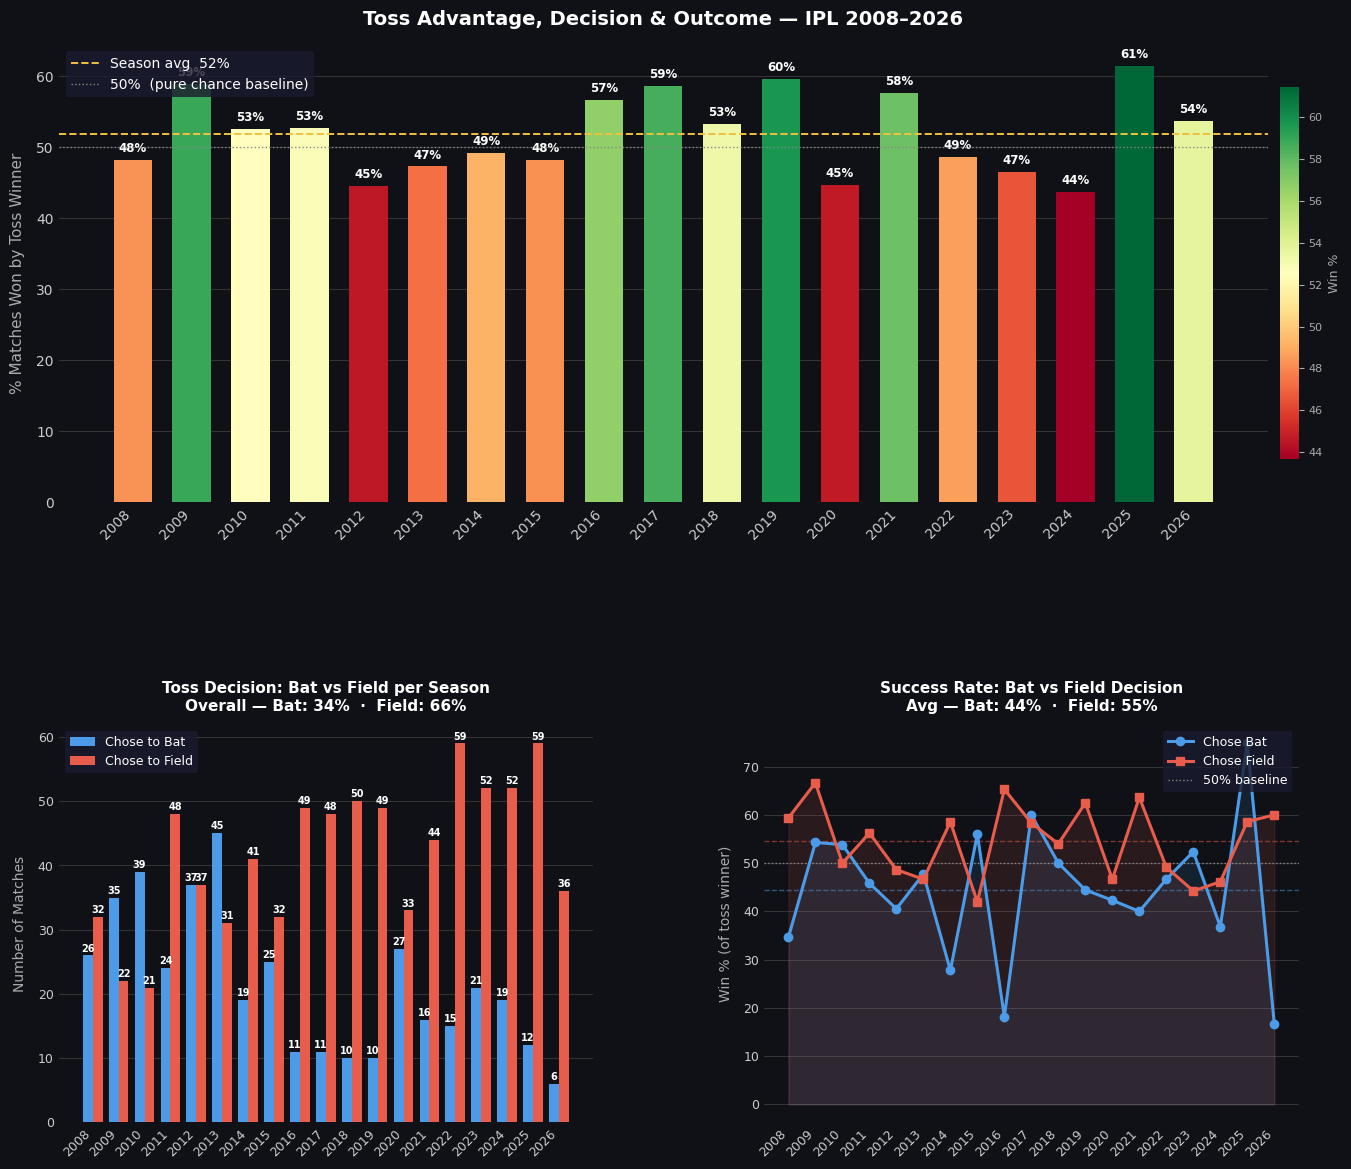

In [17]:
plot_toss_analysis()

### Reading the Toss

The top chart answers the big question directly: **winning the toss does not strongly predict winning the match**. The season-by-season conversion rate hovers close to the 50% coin-flip baseline, confirming that the toss is more ceremonial than decisive — in most seasons it's effectively a random split.

What *has* changed is the decision. The bottom-left panel shows a clear strategic shift — **fielding first has become the dominant preference** in modern IPL. Captains increasingly back their batting depth to chase any total, and knowing the exact target removes the guesswork of setting one. Early seasons saw a more even split; by 2017 onwards, field-first became the clear default.

Yet the bottom-right panel adds the counterpoint: **win rates for bat and field decisions sit close to each other and to 50%** in almost every season. Neither batting first nor chasing is a reliable structural edge — the toss advantage is largely mythologised. Execution on the day matters far more than calling heads or tails.

---

*Dataset: IPL ball-by-ball data 2008–2026 · Playoffs included · Super overs excluded from scoring averages*